# Adam César Mackowiak Pellón

In [1]:
#Import packages

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import networkx as nx
import community as community_louvain
from networkx.algorithms.community.quality import modularity
from networkx.algorithms.community import greedy_modularity_communities, girvan_newman, partition_quality
from matplotlib import cm
from scipy.optimize import curve_fit
from scipy.stats import poisson, mielke
from itertools import cycle
import seaborn as sns
import powerlaw


In [2]:
G = nx.read_edgelist(r"C:\Users\magic\OneDrive\Desktop\Programas\Python_programs\Complex_networks\Complex_networks_report\my_project\power_grid_network\edges.csv", delimiter=",", nodetype = int)

# Number of nodes, number of edges and density 

In [3]:
n = len(G)
m = len(G.edges())
density = nx.density(G)
average_degree = sum(dict(G.degree()).values()) / n
std_dev_average_degree = np.std([degree for node, degree in G.degree()])

print("Number of nodes: ", n)
print("Average degree: ", average_degree)
print("Standard deviation of the average degree: ", std_dev_average_degree)
print("Number of edges: ", m)
print("Density: ", density)


Number of nodes:  4941
Average degree:  2.66909532483303
Standard deviation of the average degree:  1.7912722617587216
Number of edges:  6594
Density:  0.0005403026973346214


# Average and global clustering 
Here we compute the value of the Watts-Strogatz clustering coefficient and the Newman transitivity

In [4]:
C_bar = nx.average_clustering(G)
C = nx.transitivity(G)

print("Average clustering coefficient: ", C_bar)
print("Transitivity: ", C)


Average clustering coefficient:  0.08010361108159714
Transitivity:  0.10315322452860086


# Average path length and diameter of the network

In [5]:
average_paht_length = nx.average_shortest_path_length(G)
diameter = nx.diameter(G)

print("Average path length: ", average_paht_length)
print("Diameter: ", diameter)

Average path length:  18.989185424445708
Diameter:  46


# Degree distribution

Here we will plot the PDF and CDF and try to fit both to more than one distribution.

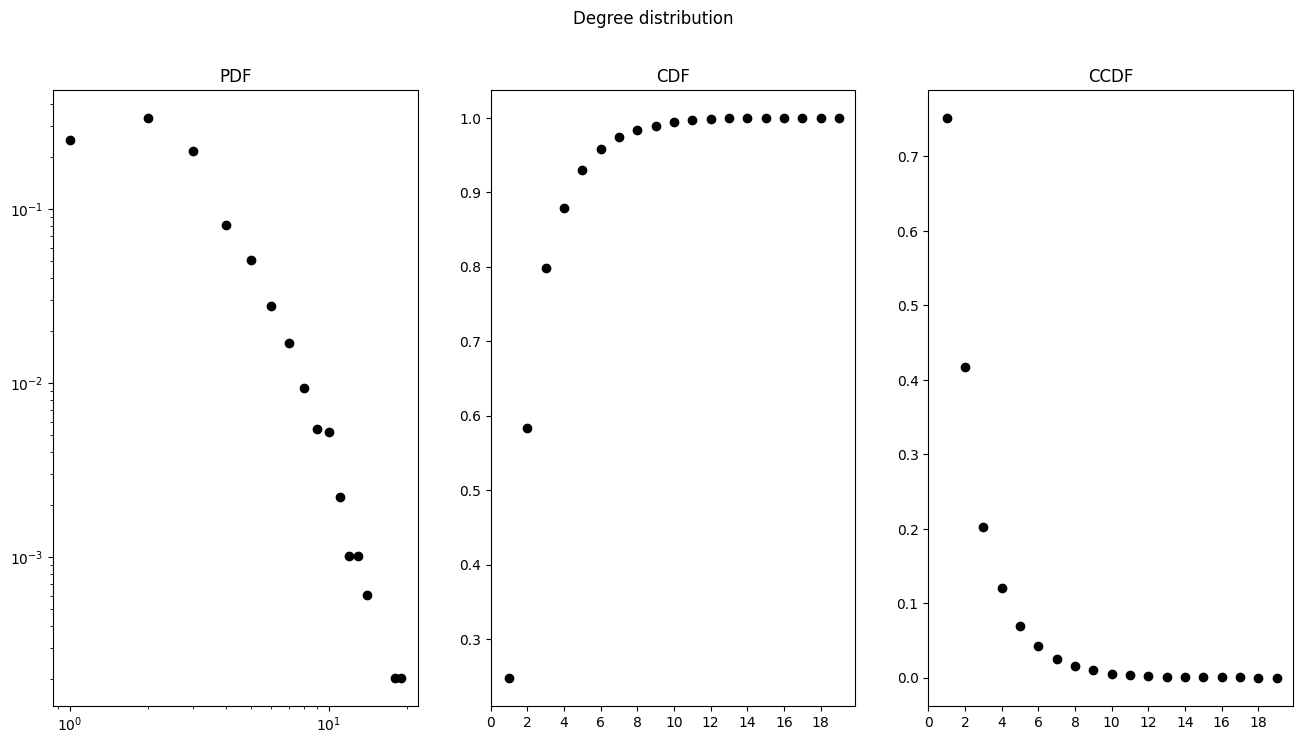

In [43]:
degree_distrib = nx.degree_histogram(G)
degree_distrib = np.array(degree_distrib)[1:]
degree_distrib = degree_distrib/sum(degree_distrib)
cdf = np.cumsum(degree_distrib)


# Fit the data
x_data = np.arange(1, len(degree_distrib) + 1)
y_data = degree_distrib


# Plot in a (1, 2) figure with logarithmic scale in both y and x
fig, axs = plt.subplots(1, 3, figsize=(16, 8))
fig.suptitle('Degree distribution')
axs[0].plot(x_data, y_data, 'o', color = 'black')
axs[0].set_title('PDF')
axs[0].set_xticks(np.arange(0, len(degree_distrib), 2))  # Set x-ticks to even numbers
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[1].plot(x_data, cdf, 'o', color = 'black')
axs[1].set_title('CDF')
axs[1].set_xticks(np.arange(0, len(cdf), 2))  # Set x-ticks to even numbers
ccdf = 1 - cdf
axs[2].plot(x_data, ccdf, 'o', color='black')
axs[2].set_title('CCDF')
axs[2].set_xticks(np.arange(0, len(ccdf), 2))  # Set x-ticks to even numbers
plt.show()


Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit
Power-law parameters: [np.float64(1.4958965970313298), np.float64(0.005262092693786682)]
Power-law errors: [0.39600034 0.        ]
Power-law 2 parameters: [0.32514107 0.96169707]
Power-law 2 errors: [0.05380616 0.18646133]
Exponential parameters: [0.45662711 0.34921539]
Exponential errors: [0.06554054 0.05896123]
Power-law + Exponential parameters: [ 1.12126306 -2.58574578  1.50307099]
Power-law + Exponential errors: [0.07984914 0.1513061  0.0769957 ]
Mielke parameters: [8.61815798 2.07560523]
Mielke errors: [0.37676328 0.05328513]
Poisson parameters: [2.14093642]
Poisson errors: [0.09356934]
Log-likelihood for power-law fit: -2299.3371363950096
Log-likelihood for power-law 2 fit: 28.466714124437797
Log-likelihood for exponential fit: 36.44476221595798
Log-likelihood for power-law + exponential fit: 67.18901182046037
Log-likelihood for Mielke fit: 62.105341823448995
Log-likelihood for Poisson fit: 49.89051178166872


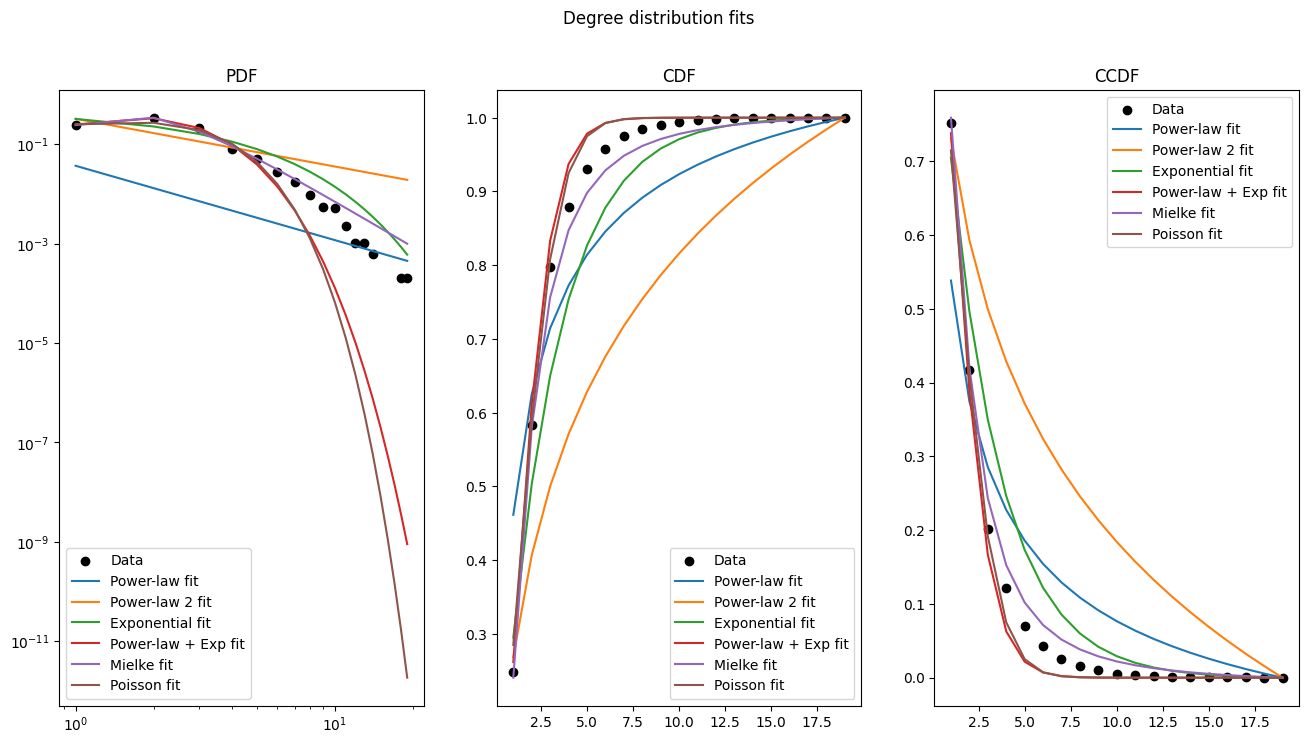

In [44]:


# Points for fitting
x_fit = x_data
y_fit = y_data

# Normalize the y_fit data
y_fit = y_fit / sum(y_fit)


# Define distributions
def power_law(x, a, b):
    return a * x**(-b)

def exponential(x, a, b):
    return a * np.exp(-b * x)

def power_law_exponential(x, a, b, c):
    return a * x**(-b) * np.exp(-c * x)

def mielke_pdf(x, k, s):
    return mielke.pdf(x, k, s)

def poisson_pdf(x, mu):
    return poisson.pmf(x, mu)

# Fit distributions and get errors
fit = powerlaw.Fit(y_fit)
alpha = fit.power_law.alpha
xmin = fit.power_law.xmin
params_power_law = [alpha,xmin]
cov_power_law = np.diag([fit.power_law.sigma, 0])  # Assuming no covariance for simplicity

params_power_law_2,cov_power_law_2 = curve_fit(power_law, x_fit, y_fit, maxfev=100000)
params_exponential, cov_exponential = curve_fit(exponential, x_fit, y_fit, maxfev=100000)
params_power_law_exp, cov_power_law_exp = curve_fit(power_law_exponential, x_fit, y_fit, maxfev=100000)
params_mielke, cov_mielke = curve_fit(mielke_pdf, x_fit, y_fit, maxfev=100000)
params_poisson, cov_poisson = curve_fit(poisson_pdf, x_fit, y_fit, maxfev=100000)

errors_power_law = np.sqrt(np.diag(cov_power_law))
errors_power_law_2 = np.sqrt(np.diag(cov_power_law_2))
errors_exponential = np.sqrt(np.diag(cov_exponential))
errors_power_law_exp = np.sqrt(np.diag(cov_power_law_exp))
errors_mielke = np.sqrt(np.diag(cov_mielke))
errors_poisson = np.sqrt(np.diag(cov_poisson))

print("Power-law parameters:", params_power_law)
print("Power-law errors:", errors_power_law)
print("Power-law 2 parameters:", params_power_law_2)
print("Power-law 2 errors:", errors_power_law_2)
print("Exponential parameters:", params_exponential)
print("Exponential errors:", errors_exponential)
print("Power-law + Exponential parameters:", params_power_law_exp)
print("Power-law + Exponential errors:", errors_power_law_exp)
print("Mielke parameters:", params_mielke)
print("Mielke errors:", errors_mielke)
print("Poisson parameters:", params_poisson)
print("Poisson errors:", errors_poisson)

power_law_pdf_fit = fit.power_law.pdf(x_fit)
power_law_pdf_fit_2 = power_law(x_fit, *params_power_law_2)
exponential_pdf_fit = exponential(x_fit, *params_exponential)
power_law_exp_pdf_fit = power_law_exponential(x_fit, *params_power_law_exp)
mielke_pdf_fit = mielke_pdf(x_fit, *params_mielke)
poisson_pdf_fit = poisson_pdf(x_fit, *params_poisson)

# Now we compute the log-likelihood to have a statistical estimator.
def residuals(f):
    return y_data - f

def sigma2(f):
    return np.var(f)

# Compute the residuals
residuals_power_law = residuals(power_law(x_fit, *params_power_law))
residuals_power_law_2 = residuals(power_law(x_fit, *params_power_law_2))
residuals_exponential = residuals(exponential(x_fit, *params_exponential))
residuals_power_law_exp = residuals(power_law_exponential(x_fit, *params_power_law_exp))
residuals_mielke = residuals(mielke_pdf(x_fit, *params_mielke))
residuals_poisson = residuals(poisson_pdf(x_fit, *params_poisson))

# Compute log-likelihood
n = len(y_data)
log_likelihood_power_law_fit = -0.5 * n * np.log(2 * np.pi * sigma2(residuals_power_law)) - np.sum(residuals_power_law**2) / (2 * sigma2(residuals_power_law))
log_likelihood_power_law_fit_2 = -0.5 * n * np.log(2 * np.pi * sigma2(residuals_power_law_2)) - np.sum(residuals_power_law_2**2) / (2 * sigma2(residuals_power_law_2))
log_likelihood_exponential_fit = -0.5 * n * np.log(2 * np.pi * sigma2(residuals_exponential)) - np.sum(residuals_exponential**2) / (2 * sigma2(residuals_exponential))
log_likelihood_power_law_exp_fit = -0.5 * n * np.log(2 * np.pi * sigma2(residuals_power_law_exp)) - np.sum(residuals_power_law_exp**2) / (2 * sigma2(residuals_power_law_exp))
log_likelihood_mielke_fit = -0.5 * n * np.log(2 * np.pi * sigma2(residuals_mielke)) - np.sum(residuals_mielke**2) / (2 * sigma2(residuals_mielke))
log_likelihood_poisson_fit = -0.5 * n * np.log(2 * np.pi * sigma2(residuals_poisson)) - np.sum(residuals_poisson**2) / (2 * sigma2(residuals_poisson))

# Now we print the log-likelihood
print("Log-likelihood for power-law fit:", log_likelihood_power_law_fit)
print("Log-likelihood for power-law 2 fit:", log_likelihood_power_law_fit_2)
print("Log-likelihood for exponential fit:", log_likelihood_exponential_fit)
print("Log-likelihood for power-law + exponential fit:", log_likelihood_power_law_exp_fit)
print("Log-likelihood for Mielke fit:", log_likelihood_mielke_fit)
print("Log-likelihood for Poisson fit:", log_likelihood_poisson_fit)


power_law_cdf_fit = np.cumsum(power_law_pdf_fit) 
power_law_cdf_fit_2 = np.cumsum(power_law_pdf_fit_2) 
exponential_cdf_fit = np.cumsum(exponential_pdf_fit)
power_law_exp_cdf_fit = np.cumsum(power_law_exp_pdf_fit)
mielke_cdf_fit = np.cumsum(mielke_pdf_fit) 
poisson_cdf_fit = np.cumsum(poisson_pdf_fit) 

# Normalize the CDF fits
power_law_cdf_fit /= power_law_cdf_fit[-1]
power_law_cdf_fit_2 /= power_law_cdf_fit_2[-1]
exponential_cdf_fit /= exponential_cdf_fit[-1]
power_law_exp_cdf_fit /= power_law_exp_cdf_fit[-1]
mielke_cdf_fit /= mielke_cdf_fit[-1]
poisson_cdf_fit /= poisson_cdf_fit[-1]


# Plot in a (1, 3) figure 
fig, axs = plt.subplots(1, 3, figsize=(16, 8))
fig.suptitle('Degree distribution fits')
axs[0].scatter(x_data, y_data, label="Data", color="black")
axs[0].plot(x_fit, power_law_pdf_fit, label="Power-law fit")
axs[0].plot(x_fit, power_law_pdf_fit_2, label="Power-law 2 fit")
axs[0].plot(x_fit, exponential_pdf_fit, label="Exponential fit")
axs[0].plot(x_fit, power_law_exp_pdf_fit, label="Power-law + Exp fit")
axs[0].plot(x_fit, mielke_pdf_fit, label="Mielke fit")
axs[0].plot(x_fit, poisson_pdf_fit, label="Poisson fit")
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_title('PDF')
axs[0].legend()

axs[1].scatter(x_data, cdf, label="Data", color="black")
axs[1].plot(x_fit,power_law_cdf_fit , label="Power-law fit")
axs[1].plot(x_fit, power_law_cdf_fit_2, label="Power-law 2 fit")
axs[1].plot(x_fit, exponential_cdf_fit, label="Exponential fit")
axs[1].plot(x_fit, power_law_exp_cdf_fit, label="Power-law + Exp fit")
axs[1].plot(x_fit, mielke_cdf_fit, label="Mielke fit")
axs[1].plot(x_fit, poisson_cdf_fit, label="Poisson fit")
axs[1].set_title('CDF')
axs[1].legend()

axs[2].scatter(x_data, ccdf, label="Data", color="black")
axs[2].plot(x_fit, (1 - power_law_cdf_fit), label="Power-law fit")
axs[2].plot(x_fit, (1 - power_law_cdf_fit_2), label="Power-law 2 fit")
axs[2].plot(x_fit, (1 - exponential_cdf_fit), label="Exponential fit")
axs[2].plot(x_fit, (1 - power_law_exp_cdf_fit), label="Power-law + Exp fit")
axs[2].plot(x_fit, (1 - mielke_cdf_fit), label="Mielke fit")
axs[2].plot(x_fit, (1 - poisson_cdf_fit), label="Poisson fit")
axs[2].set_title('CCDF')
axs[2].legend()

plt.show()


In [103]:
# Define the parameters and their errors
params_dict = {
    'Power-law': (params_power_law, errors_power_law),
    'Power-law 2': (params_power_law_2, errors_power_law),
    'Exponential': (params_exponential, errors_exponential),
    'Power-law + Exponential': (params_power_law_exp, errors_power_law_exp),
    'Mielke': (params_mielke, errors_mielke),
    'Poisson': (params_poisson, errors_poisson)
}

# Create a DataFrame to hold the parameters and their errors
params_df = pd.DataFrame({
    'Distribution': list(params_dict.keys()),
    'Parameters': [', '.join(f'{param} ± {error}' for param, error in zip(params, errors)) for params, errors in params_dict.values()]
})

# Convert the DataFrame to a LaTeX table
latex_table_params = params_df.to_latex(index=False)
print(latex_table_params)


\begin{tabular}{ll}
\toprule
Distribution & Parameters \\
\midrule
Power-law & 1.4958965970313298 ± 0.39600034476572055, 0.005262092693786682 ± 0.0 \\
Power-law 2 & 0.32514107013360766 ± 0.39600034476572055, 0.9616970688061273 ± 0.0 \\
Exponential & 0.4566271147829099 ± 0.06554054335031645, 0.34921538924916823 ± 0.058961228003096236 \\
Power-law + Exponential & 1.1212630591405028 ± 0.07984913557765848, -2.585745783574814 ± 0.15130609931641337, 1.503070988777665 ± 0.0769956999016522 \\
Mielke & 8.6181579770033 ± 0.3767632799617626, 2.0756052267437846 ± 0.05328513114805047 \\
Poisson & 2.1409364211065847 ± 0.09356933919146433 \\
\bottomrule
\end{tabular}



# Fits to the degree distribution and to the cumulative distribution

# Top 25 most central nodes

In [15]:

# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G)
katz_centrality = nx.katz_centrality(G)
pagerank_centrality = nx.pagerank(G)
subgraph_centrality = nx.subgraph_centrality(G)

# Get the top 25 nodes for each centrality measure
top_25_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:25]
top_25_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:25]
top_25_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:25]
top_25_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:25]
top_25_katz = sorted(katz_centrality.items(), key=lambda x: x[1], reverse=True)[:25]
top_25_pagerank = sorted(pagerank_centrality.items(), key=lambda x: x[1], reverse=True)[:25]
top_25_subgraph = sorted(subgraph_centrality.items(), key=lambda x: x[1], reverse=True)[:25]

sc_cent = nx.subgraph_centrality(G)
sort_sc_cent = sorted(zip(sc_cent.values(), sc_cent.keys()), reverse=True)[:25]
# Create a DataFrame to hold the top 25 nodes for each centrality measure
top_25_df = pd.DataFrame({
    'Rank': range(1, 26),
    'Degree Centrality': [node for node, _ in top_25_degree],
    'Closeness Centrality': [node for node, _ in top_25_closeness],
    'Betweenness Centrality': [node for node, _ in top_25_betweenness],
    'Eigenvector Centrality': [node for node, _ in top_25_eigenvector],
    'Katz Centrality': [node for node, _ in top_25_katz],
    'PageRank Centrality': [node for node, _ in top_25_pagerank],
    'Subgraph Centrality': [node for node, _ in top_25_subgraph]
})

# Display the DataFrame
print(top_25_df)


    Rank  Degree Centrality  Closeness Centrality  Betweenness Centrality  \
0      1               2553                  1308                    4164   
1      2               4458                  2594                    2543   
2      3                831                  2605                    1243   
3      4               3468                  1131                    4219   
4      5               4345                  2606                    2528   
5      6               2382                  1243                    1267   
6      7               2542                  1476                    1308   
7      8               2575                  2557                    1244   
8      9               2585                  2528                     426   
9     10               3895                  2532                    2606   
10    11               1224                  2612                    2594   
11    12               2434                  2543                    2605   

In [16]:
# Now I will print it in a way to copy and paste into my latex document
latex_table = top_25_df.to_latex(index=False)
print(latex_table)


\begin{tabular}{rrrrrrrr}
\toprule
Rank & Degree Centrality & Closeness Centrality & Betweenness Centrality & Eigenvector Centrality & Katz Centrality & PageRank Centrality & Subgraph Centrality \\
\midrule
1 & 2553 & 1308 & 4164 & 4381 & 4345 & 4458 & 4345 \\
2 & 4458 & 2594 & 2543 & 4345 & 4381 & 831 & 4381 \\
3 & 831 & 2605 & 1243 & 4336 & 4336 & 3468 & 4352 \\
4 & 3468 & 1131 & 4219 & 4332 & 4352 & 2553 & 4384 \\
5 & 4345 & 2606 & 2528 & 4352 & 4332 & 1224 & 4336 \\
6 & 2382 & 1243 & 1267 & 4384 & 4395 & 597 & 4395 \\
7 & 2542 & 1476 & 1308 & 4402 & 4384 & 2382 & 4332 \\
8 & 2575 & 2557 & 1244 & 4347 & 4373 & 2575 & 4373 \\
9 & 2585 & 2528 & 426 & 4395 & 4402 & 2439 & 4402 \\
10 & 3895 & 2532 & 2606 & 4373 & 2553 & 3895 & 4361 \\
11 & 1224 & 2612 & 2594 & 4361 & 4361 & 3355 & 4401 \\
12 & 2434 & 2543 & 2605 & 4398 & 4347 & 2434 & 4347 \\
13 & 2439 & 4219 & 69 & 4401 & 4392 & 2542 & 4392 \\
14 & 2617 & 1125 & 108 & 4413 & 4401 & 2617 & 4413 \\
15 & 2662 & 2618 & 1167 & 4408 & 4372 &

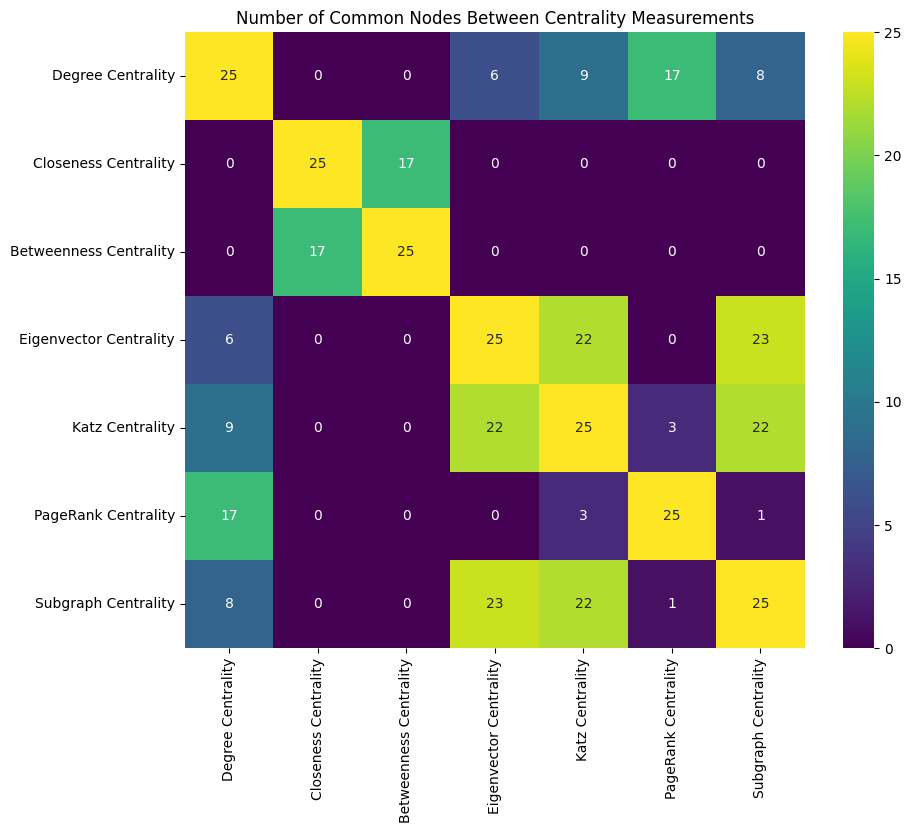

In [20]:

# Extract the top 25 nodes for each centrality measure
centrality_measures = {
    'Degree Centrality': [node for node, _ in top_25_degree],
    'Closeness Centrality': [node for node, _ in top_25_closeness],
    'Betweenness Centrality': [node for node, _ in top_25_betweenness],
    'Eigenvector Centrality': [node for node, _ in top_25_eigenvector],
    'Katz Centrality': [node for node, _ in top_25_katz],
    'PageRank Centrality': [node for node, _ in top_25_pagerank],
    'Subgraph Centrality': [node for node, _ in top_25_subgraph]
}

# Create a matrix to store the number of common nodes
common_nodes_matrix = pd.DataFrame(index=centrality_measures.keys(), columns=centrality_measures.keys())

# Calculate the number of common nodes between each pair of centrality measures
for measure1, nodes1 in centrality_measures.items():
    for measure2, nodes2 in centrality_measures.items():
        common_nodes_matrix.loc[measure1, measure2] = len(set(nodes1) & set(nodes2))

# Convert the matrix to integer type
common_nodes_matrix = common_nodes_matrix.astype(int)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(common_nodes_matrix, annot=True, cmap='viridis', fmt='d')
plt.title('Number of Common Nodes Between Centrality Measurements')
plt.show()

# Assortativity of the network

In [43]:
assortativity = nx.degree_assortativity_coefficient(G)
print("Assortativity coefficient: ", assortativity)

Assortativity coefficient:  0.0034569877442048825


# Bipartivity index

In [44]:
def get_bipartivity(G):
    A = nx.to_numpy_array(G)
    eigvals, _ = np.linalg.eigh(A)
    return sum(np.cosh(v) - np.sinh(v) for v in eigvals)/sum(np.exp(v) for v in eigvals)

In [11]:
print(f"The bipartivity index that we have seen in class is: {get_bipartivity(G)}")

The bipartivity index that we have seen in class is: 0.7259174951240258


# Part 2

# Erdös-Rényi

In [ ]:
# Generate 10 random realizations of the Erdös-Rényi model
n = len(G)
m = len(G.edges())
p = m / (n * (n - 1) / 2)

er_graphs = [nx.gnm_random_graph(n, m, p) for _ in range(10)]

# Calculate the required parameters for each ER graph
er_metrics = {
    'average_clustering': [],
    'transitivity': [],
    'average_path_length': [],
    'diameter': [],
    'degree_distribution': [],
    'cdf': [],
    'assortativity': [],
    'bipartivity_index': []
}

for er_graph in er_graphs:
    er_metrics['average_clustering'].append(nx.average_clustering(er_graph))
    er_metrics['transitivity'].append(nx.transitivity(er_graph))
    
    if nx.is_connected(er_graph):
        er_metrics['average_path_length'].append(nx.average_shortest_path_length(er_graph))
        er_metrics['diameter'].append(nx.diameter(er_graph))
    else:
        largest_cc = max(nx.connected_components(er_graph), key=len)
        subgraph = er_graph.subgraph(largest_cc)
        er_metrics['average_path_length'].append(nx.average_shortest_path_length(subgraph))
        er_metrics['diameter'].append(nx.diameter(subgraph))
    
    degree_distrib = nx.degree_histogram(er_graph)
    degree_distrib = np.array(degree_distrib)
    degree_distrib = degree_distrib / sum(degree_distrib)
    er_metrics['degree_distribution'].append(degree_distrib)
    er_metrics['cdf'].append(np.cumsum(degree_distrib))
    
    er_metrics['assortativity'].append(nx.degree_assortativity_coefficient(er_graph))
    er_metrics['bipartivity_index'].append(get_bipartivity(er_graph))

    """
    MIRAR QUE LA NORMALIZACION SE HAGA CORRECTAMENTE TANTO EN ESTE MODELO COMO EN EL RESTO
    PONER X_DATA E Y_DATA EN EL RESTO DE PLOTS
    MIRAR QUE SE ESOJA LOS DATOS DEL SUBGRAPH
    """



In [46]:
# Pad degree_distribution and cdf arrays to the same length
max_length = max(len(arr) for arr in er_metrics['degree_distribution'])
for i in range(len(er_metrics['degree_distribution'])):
    er_metrics['degree_distribution'][i] = np.pad(er_metrics['degree_distribution'][i], (0, max_length - len(er_metrics['degree_distribution'][i])), 'constant')
    er_metrics['cdf'][i] = np.pad(er_metrics['cdf'][i], (0, max_length - len(er_metrics['cdf'][i])), 'constant')

# Calculate averages and standard deviations
er_averages = {key: np.mean(values, axis=0) for key, values in er_metrics.items()}
er_stddevs = {key: np.std(values, axis=0) for key, values in er_metrics.items()}





In [47]:
# Compare with the real network
print("\nComparison with the real network:")
print(f"Average clustering coefficient: Real = {C_bar}, ER Average = {er_averages['average_clustering']}, ER Std Dev = {er_stddevs['average_clustering']}")
print(f"Transitivity: Real = {C}, ER Average = {er_averages['transitivity']}, ER Std Dev = {er_stddevs['transitivity']}")
print(f"Average path length: Real = {average_paht_length}, ER Average = {er_averages['average_path_length']}, ER Std Dev = {er_stddevs['average_path_length']}")
print(f"Diameter: Real = {diameter}, ER Average = {er_averages['diameter']}, ER Std Dev = {er_stddevs['diameter']}")
print(f"Assortativity: Real = {assortativity}, ER Average = {er_averages['assortativity']}, ER Std Dev = {er_stddevs['assortativity']}")
print(f"Bipartivity index: Real = {get_bipartivity(G)}, ER Average = {er_averages['bipartivity_index']}, ER Std Dev = {er_stddevs['bipartivity_index']}")



Comparison with the real network:
Average clustering coefficient: Real = 0.08010361108159714, ER Average = 0.00047795589689943066, ER Std Dev = 0.000347880547321257
Transitivity: Real = 0.10315322452860086, ER Average = 0.0005632744609760038, ER Std Dev = 0.0002855174050517081
Average path length: Real = 18.989185424445708, ER Average = 8.491710218079856, ER Std Dev = 0.03563635949168954
Diameter: Real = 46, ER Average = 19.3, ER Std Dev = 1.1874342087037917
Assortativity: Real = 0.0034569877442048825, ER Average = 0.0008135363247370518, ER Std Dev = 0.010976377820568766
Bipartivity index: Real = 0.7259174951240253, ER Average = 0.9987880247608631, ER Std Dev = 0.00044185408210755626


In [48]:
# Find the index where the CDF starts to decrease
x_n = next(i for i in range(1, len(er_averages['cdf'])) if er_averages['cdf'][i] < er_averages['cdf'][i - 1])

# Take values until that index
er_degree_distrib_truncated = er_averages['degree_distribution'][:x_n]
er_cdf_truncated = er_averages['cdf'][:x_n]

# Normalize the truncated arrays
er_degree_distrib_truncated /= er_degree_distrib_truncated.sum()
er_cdf_truncated /= er_cdf_truncated[-1]

print("Truncated and normalized degree distribution:", er_degree_distrib_truncated)
print("Truncated and normalized CDF:", er_cdf_truncated)



Truncated and normalized degree distribution: [6.84008097e-02 1.86275304e-01 2.45991903e-01 2.20364372e-01
 1.46153846e-01 7.91093117e-02 3.51214575e-02 1.32591093e-02
 3.88663968e-03 1.19433198e-03 2.42914980e-04]
Truncated and normalized CDF: [0.06840081 0.25467611 0.50066802 0.72103239 0.86718623 0.94629555
 0.981417   0.99467611 0.99856275 0.99975709 1.        ]


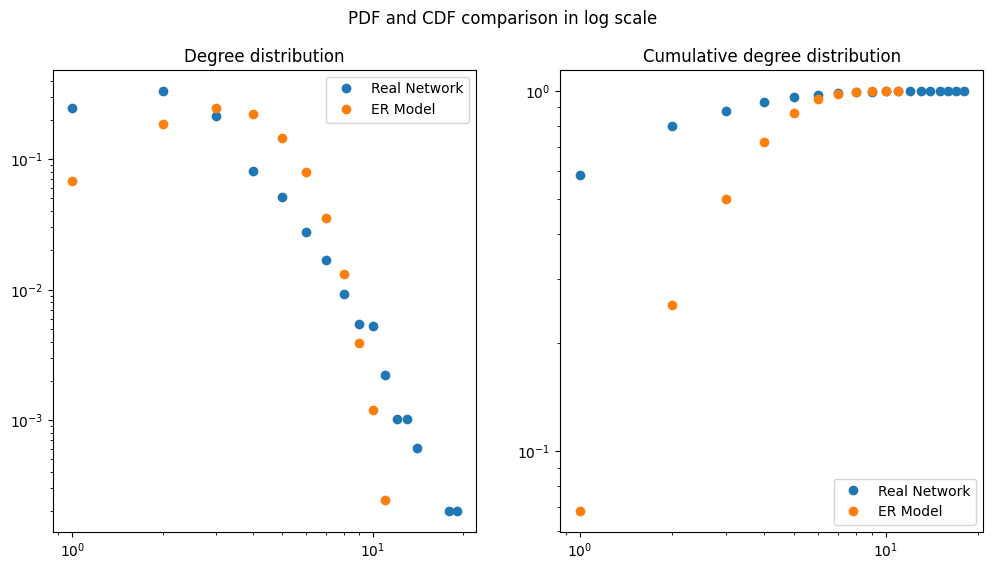

In [49]:
# Plot the degree distribution for the real network and ER model
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('PDF and CDF comparison in log scale')

# Real network
axs[0].plot(x_data, y_data, 'o', label='Real Network')
axs[0].set_title('Degree distribution')
axs[0].set_xticks(np.arange(0, len(degree_distrib), 2))
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[1].plot(cdf, 'o', label='Real Network')
axs[1].set_title('Cumulative degree distribution')
axs[1].set_xticks(np.arange(0, len(cdf), 2))
axs[1].set_yscale('log')
axs[1].set_xscale('log')

er_degree_distrib_avg = er_degree_distrib_truncated
er_cdf_avg = er_cdf_truncated
er_degree_distrib_std = er_stddevs['degree_distribution'][:x_n]
er_cdf_std = er_stddevs['cdf'][:x_n]

axs[0].plot(np.arange(1, len(er_degree_distrib_avg) + 1), er_degree_distrib_avg, 'o', label='ER Model')
axs[1].plot(np.arange(1, len(er_cdf_avg) + 1), er_cdf_avg, 'o', label='ER Model')
axs[0].legend()
axs[1].legend()
plt.show()

# Barabási-Albert

In [76]:
# Generate 10 random realizations of the Barabási-Albert model

# Number of edges to attach from a new node to existing nodes

#m = len(G.edges()) // len(G.nodes()) # ->This would lead to a tres structure where the clustesting coefficients and the transivity are way too low and the bipartivity is basically 1.
m = 2
ba_graphs = [nx.barabasi_albert_graph(len(G.nodes()), m) for _ in range(10)]

# Calculate the required parameters for each BA graph
ba_metrics = {
    'average_clustering': [],
    'transitivity': [],
    'average_path_length': [],
    'diameter': [],
    'degree_distribution': [],
    'cdf': [],
    'assortativity': [],
    'bipartivity_index': []
}

for ba_graph in ba_graphs:
    ba_metrics['average_clustering'].append(nx.average_clustering(ba_graph))
    ba_metrics['transitivity'].append(nx.transitivity(ba_graph))
    
    if nx.is_connected(ba_graph):
        ba_metrics['average_path_length'].append(nx.average_shortest_path_length(ba_graph))
        ba_metrics['diameter'].append(nx.diameter(ba_graph))
    else:
        largest_cc = max(nx.connected_components(ba_graph), key=len)
        subgraph = ba_graph.subgraph(largest_cc)
        ba_metrics['average_path_length'].append(nx.average_shortest_path_length(subgraph))
        ba_metrics['diameter'].append(nx.diameter(subgraph))
    
    degree_distrib = nx.degree_histogram(ba_graph)
    degree_distrib = np.array(degree_distrib)
    degree_distrib = degree_distrib / sum(degree_distrib)
    ba_metrics['degree_distribution'].append(degree_distrib)
    ba_metrics['cdf'].append(np.cumsum(degree_distrib))
    
    ba_metrics['assortativity'].append(nx.degree_assortativity_coefficient(ba_graph))
    ba_metrics['bipartivity_index'].append(get_bipartivity(ba_graph))




In [77]:
# Pad degree_distribution and cdf arrays to the same length
max_length = max(len(arr) for arr in ba_metrics['degree_distribution'])
for i in range(len(ba_metrics['degree_distribution'])):
    ba_metrics['degree_distribution'][i] = np.pad(ba_metrics['degree_distribution'][i], (0, max_length - len(ba_metrics['degree_distribution'][i])), 'constant')
    ba_metrics['cdf'][i] = np.pad(ba_metrics['cdf'][i], (0, max_length - len(ba_metrics['cdf'][i])), 'constant')

# Calculate averages and standard deviations
ba_averages = {key: np.mean(values, axis=0) for key, values in ba_metrics.items()}
ba_stddevs = {key: np.std(values, axis=0) for key, values in ba_metrics.items()}





In [78]:
# Compare with the real network
print("\nComparison with the real network:")
print(f"Average clustering coefficient: Real = {C_bar}, BA Average = {ba_averages['average_clustering']}, BA Std Dev = {ba_stddevs['average_clustering']}")
print(f"Transitivity: Real = {C}, BA Average = {ba_averages['transitivity']}, BA Std Dev = {ba_stddevs['transitivity']}")
print(f"Average path length: Real = {average_paht_length}, BA Average = {ba_averages['average_path_length']}, BA Std Dev = {ba_stddevs['average_path_length']}")
print(f"Diameter: Real = {diameter}, BA Average = {ba_averages['diameter']}, BA Std Dev = {ba_stddevs['diameter']}")
print(f"Assortativity: Real = {assortativity}, BA Average = {ba_averages['assortativity']}, BA Std Dev = {ba_stddevs['assortativity']}")
print(f"Bipartivity index: Real = {get_bipartivity(G)}, BA Average = {ba_averages['bipartivity_index']}, BA Std Dev = {ba_stddevs['bipartivity_index']}")



Comparison with the real network:
Average clustering coefficient: Real = 0.08010361108159714, BA Average = 0.007886783068699804, BA Std Dev = 0.0007472613103313944
Transitivity: Real = 0.10315322452860086, BA Average = 0.0028038190000580806, BA Std Dev = 0.00027698895501981744
Average path length: Real = 18.989185424445708, BA Average = 4.732654939623591, BA Std Dev = 0.050054479359311205
Diameter: Real = 46, BA Average = 8.3, BA Std Dev = 0.45825756949558394
Assortativity: Real = 0.0034569877442048825, BA Average = -0.05452456909054767, BA Std Dev = 0.0050685526615165365
Bipartivity index: Real = 0.7259174951240253, BA Average = 0.40824091685584507, BA Std Dev = 0.0634590590072072


In [79]:
# Find the index where the CDF starts to decrease
x_n = next(i for i in range(1, len(ba_averages['cdf'])) if ba_averages['cdf'][i] < ba_averages['cdf'][i - 1])

# Take values until that index
ba_degree_distrib_truncated = ba_averages['degree_distribution'][:x_n]
ba_cdf_truncated = ba_averages['cdf'][:x_n]

# Normalize the truncated arrays
ba_degree_distrib_truncated /= ba_degree_distrib_truncated.sum()
ba_cdf_truncated /= ba_cdf_truncated[-1]

print("Truncated and normalized degree distribution:", ba_degree_distrib_truncated)
print("Truncated and normalized CDF:", ba_cdf_truncated)

Truncated and normalized degree distribution: [0.00000000e+00 0.00000000e+00 4.96375638e-01 2.04685349e-01
 9.98623147e-02 5.71393861e-02 3.52514781e-02 2.26168300e-02
 1.69069410e-02 1.19462218e-02 8.78755973e-03 7.16773305e-03
 5.50741071e-03 4.57601037e-03 3.84708836e-03 2.93593585e-03
 2.89544019e-03 2.10577468e-03 1.88304851e-03 1.47809184e-03
 1.33635701e-03 9.31400340e-04 8.30161173e-04 9.11152507e-04
 9.51648174e-04 7.89665506e-04 6.68178505e-04 7.89665506e-04
 5.06195837e-04 5.66939337e-04 4.65700170e-04 3.44213169e-04
 4.25204503e-04 2.63221835e-04 3.84708836e-04 1.41734834e-04
 1.41734834e-04 8.09913339e-05 1.82230501e-04 1.21487001e-04
 1.41734834e-04 2.02478335e-04 6.07435004e-05 1.01239167e-04
 1.61982668e-04 1.01239167e-04 1.21487001e-04 6.07435004e-05
 8.09913339e-05 2.02478335e-05 6.07435004e-05 6.07435004e-05
 1.61982668e-04 8.09913339e-05 1.01239167e-04 8.09913339e-05
 6.07435004e-05 6.07435004e-05 2.02478335e-05 8.09913339e-05
 6.07435004e-05 6.07435004e-05 0.000000

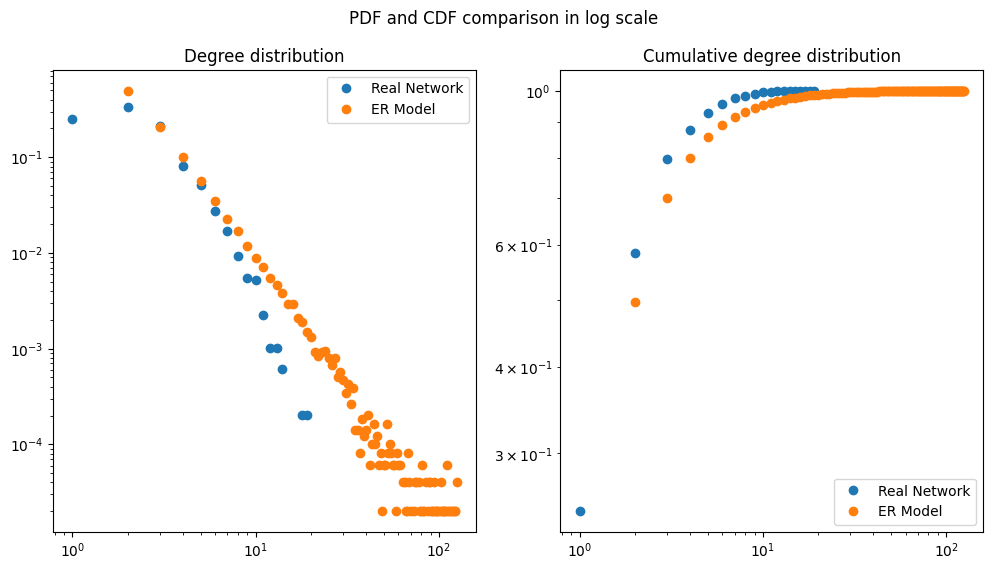

In [80]:
# Plot the degree distribution for the real network and ER model
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('PDF and CDF comparison in log scale')

# Real network
axs[0].plot(x_data, y_data, 'o', label='Real Network')
axs[0].set_title('Degree distribution')
axs[0].set_xticks(np.arange(0, len(degree_distrib), 2))
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[1].plot(x_data, cdf, 'o', label='Real Network')
axs[1].set_title('Cumulative degree distribution')
axs[1].set_xticks(np.arange(0, len(cdf), 2))
axs[1].set_yscale('log')
axs[1].set_xscale('log')


# ER model
ba_degree_distrib_avg = ba_degree_distrib_truncated
ba_cdf_avg = ba_cdf_truncated
axs[0].plot( ba_degree_distrib_avg, 'o', label='ER Model')
axs[1].plot( ba_cdf_avg, 'o', label='ER Model')

axs[0].legend()
axs[1].legend()
plt.show()


# Watts-Strogatz

This part is optional but I wanted to see how is it compared to Watts-Strogatz, the last of the three models that were assigned in the group project

In [81]:
# Generate 10 random realizations of the Watts-Strogatz model
k = 4  # Each node is joined with its k nearest neighbors in a ring topology
p = 0.2  # The probability of rewiring each edge

ws_graphs = [nx.watts_strogatz_graph(len(G.nodes()), k, p) for _ in range(10)]

# Calculate the required parameters for each WS graph
ws_metrics = {
    'average_clustering': [],
    'transitivity': [],
    'average_path_length': [],
    'diameter': [],
    'degree_distribution': [],
    'cdf': [],
    'assortativity': [],
    'bipartivity_index': []
}

for ws_graph in ws_graphs:
    ws_metrics['average_clustering'].append(nx.average_clustering(ws_graph))
    ws_metrics['transitivity'].append(nx.transitivity(ws_graph))
    
    if nx.is_connected(ws_graph):
        ws_metrics['average_path_length'].append(nx.average_shortest_path_length(ws_graph))
        ws_metrics['diameter'].append(nx.diameter(ws_graph))
    else:
        largest_cc = max(nx.connected_components(ws_graph), key=len)
        subgraph = ws_graph.subgraph(largest_cc)
        ws_metrics['average_path_length'].append(nx.average_shortest_path_length(subgraph))
        ws_metrics['diameter'].append(nx.diameter(subgraph))
    
    degree_distrib = nx.degree_histogram(ws_graph)
    degree_distrib = np.array(degree_distrib)
    degree_distrib = degree_distrib / sum(degree_distrib)
    ws_metrics['degree_distribution'].append(degree_distrib)
    ws_metrics['cdf'].append(np.cumsum(degree_distrib))
    
    ws_metrics['assortativity'].append(nx.degree_assortativity_coefficient(ws_graph))
    ws_metrics['bipartivity_index'].append(get_bipartivity(ws_graph))



In [82]:
# Pad degree_distribution and cdf arrays to the same length
max_length = max(len(arr) for arr in ws_metrics['degree_distribution'])
for i in range(len(ws_metrics['degree_distribution'])):
    ws_metrics['degree_distribution'][i] = np.pad(ws_metrics['degree_distribution'][i], (0, max_length - len(ws_metrics['degree_distribution'][i])), 'constant')
    ws_metrics['cdf'][i] = np.pad(ws_metrics['cdf'][i], (0, max_length - len(ws_metrics['cdf'][i])), 'constant')

# Calculate averages and standard deviations
ws_averages = {key: np.mean(values, axis=0) for key, values in ws_metrics.items()}
ws_stddevs = {key: np.std(values, axis=0) for key, values in ws_metrics.items()}



In [83]:
# Compare with the real network
print("\nComparison with the real network:")
print(f"Average clustering coefficient: Real = {C_bar}, WS Average = {ws_averages['average_clustering']}, WS Std Dev = {ws_stddevs['average_clustering']}")
print(f"Transitivity: Real = {C}, WS Average = {ws_averages['transitivity']}, WS Std Dev = {ws_stddevs['transitivity']}")
print(f"Average path length: Real = {average_paht_length}, WS Average = {ws_averages['average_path_length']}, WS Std Dev = {ws_stddevs['average_path_length']}")
print(f"Diameter: Real = {diameter}, WS Average = {ws_averages['diameter']}, WS Std Dev = {ws_stddevs['diameter']}")
print(f"Assortativity: Real = {assortativity}, WS Average = {ws_averages['assortativity']}, WS Std Dev = {ws_stddevs['assortativity']}")
print(f"Bipartivity index: Real = {get_bipartivity(G)}, WS Average = {ws_averages['bipartivity_index']}, WS Std Dev = {ws_stddevs['bipartivity_index']}")




Comparison with the real network:
Average clustering coefficient: Real = 0.08010361108159714, WS Average = 0.26323421131253555, WS Std Dev = 0.005398992179368254
Transitivity: Real = 0.10315322452860086, WS Average = 0.2387182815024833, WS Std Dev = 0.005650298845599227
Average path length: Real = 18.989185424445708, WS Average = 8.767390200315136, WS Std Dev = 0.06829266274593673
Diameter: Real = 46, WS Average = 15.9, WS Std Dev = 0.7000000000000001
Assortativity: Real = 0.0034569877442048825, WS Average = -0.04784989688431947, WS Std Dev = 0.00896860409297494
Bipartivity index: Real = 0.7259174951240253, WS Average = 0.629238712746661, WS Std Dev = 0.006297743430310145


In [84]:
# Find the index where the CDF starts to decrease
x_n = next(i for i in range(1, len(ws_averages['cdf'])) if ws_averages['cdf'][i] < ws_averages['cdf'][i - 1])

# Take values until that index
ws_degree_distrib_truncated = ws_averages['degree_distribution'][:x_n]
ws_cdf_truncated = ws_averages['cdf'][:x_n]

# Normalize the truncated arrays
ws_degree_distrib_truncated /= ws_degree_distrib_truncated.sum()
ws_cdf_truncated /= ws_cdf_truncated[-1]

print("Truncated and normalized degree distribution:", ws_degree_distrib_truncated)
print("Truncated and normalized CDF:", ws_cdf_truncated)

Truncated and normalized degree distribution: [0.         0.         0.02719284 0.22740342 0.5121892  0.1911598
 0.03735725 0.0046975 ]
Truncated and normalized CDF: [0.         0.         0.02719284 0.25459626 0.76678545 0.95794525
 0.9953025  1.        ]


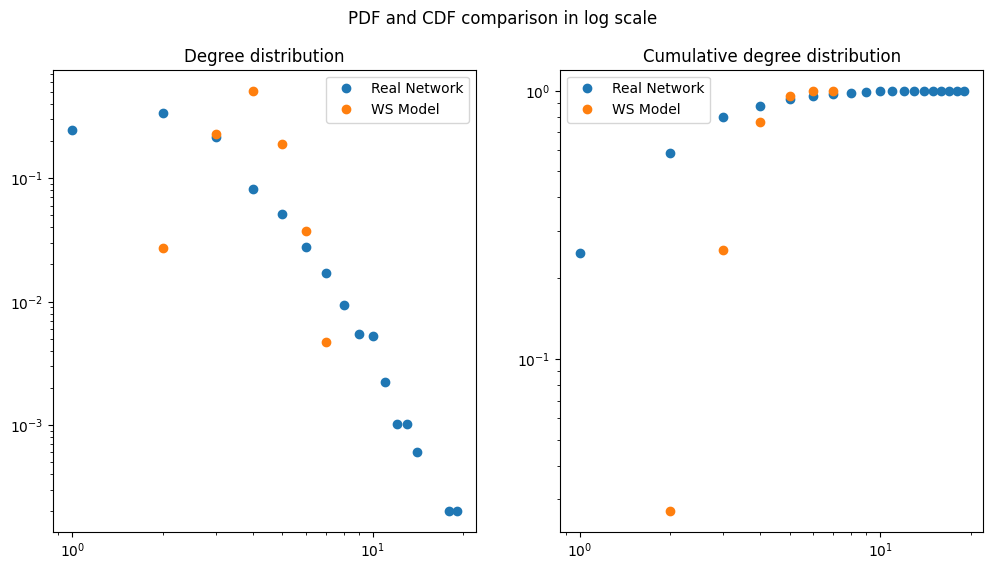

In [85]:
# Plot the degree distribution for the real network and WS model
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('PDF and CDF comparison in log scale')

# Real network
axs[0].plot(x_data, y_data, 'o', label='Real Network')
axs[0].set_title('Degree distribution')
axs[0].set_xticks(np.arange(0, len(degree_distrib), 2))
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[1].plot(x_data, cdf, 'o', label='Real Network')
axs[1].set_title('Cumulative degree distribution')
axs[1].set_xticks(np.arange(0, len(cdf), 2))
axs[1].set_yscale('log')
axs[1].set_xscale('log')

# WS model
ws_degree_distrib_avg = ws_degree_distrib_truncated
ws_cdf_avg = ws_cdf_truncated
axs[0].plot(ws_degree_distrib_avg, 'o', label='WS Model')
axs[1].plot( ws_cdf_avg, 'o', label='WS Model')

axs[0].legend()
axs[1].legend()
plt.show()

In [ ]:
# Create a DataFrame to hold the metrics
metrics_df = pd.DataFrame({
    'Metric': ['Average Clustering Coefficient', 'Transitivity', 'Average Path Length', 'Diameter', 'Assortativity', 'Bipartivity Index'],
    'Real Network': [f"{C_bar:.6f}", f"{C:.6f}", f"{average_paht_length:.6f}", f"{diameter:.6f}", f"{assortativity:.6f}", f"{get_bipartivity(G):.6f}"],
    'Erdös-Rényi': [f"{er_averages['average_clustering']:.6f} ± {er_stddevs['average_clustering']:.6f}",
                    f"{er_averages['transitivity']:.6f} ± {er_stddevs['transitivity']:.6f}",
                    f"{er_averages['average_path_length']:.6f} ± {er_stddevs['average_path_length']:.6f}",
                    f"{er_averages['diameter']:.6f} ± {er_stddevs['diameter']:.6f}",
                    f"{er_averages['assortativity']:.6f} ± {er_stddevs['assortativity']:.6f}",
                    f"{er_averages['bipartivity_index']:.6f} ± {er_stddevs['bipartivity_index']:.6f}"],
    'Barabási-Albert': [f"{ba_averages['average_clustering']:.6f} ± {ba_stddevs['average_clustering']:.6f}",
                        f"{ba_averages['transitivity']:.6f} ± {ba_stddevs['transitivity']:.6f}",
                        f"{ba_averages['average_path_length']:.6f} ± {ba_stddevs['average_path_length']:.6f}",
                        f"{ba_averages['diameter']:.6f} ± {ba_stddevs['diameter']:.6f}",
                        f"{ba_averages['assortativity']:.6f} ± {ba_stddevs['assortativity']:.6f}",
                        f"{ba_averages['bipartivity_index']:.6f} ± {ba_stddevs['bipartivity_index']:.6f}"],
    'Watts-Strogatz': [f"{ws_averages['average_clustering']:.6f} ± {ws_stddevs['average_clustering']:.6f}",
                       f"{ws_averages['transitivity']:.6f} ± {ws_stddevs['transitivity']:.6f}",
                       f"{ws_averages['average_path_length']:.6f} ± {ws_stddevs['average_path_length']:.6f}",
                       f"{ws_averages['diameter']:.6f} ± {ws_stddevs['diameter']:.6f}",
                       f"{ws_averages['assortativity']:.6f} ± {ws_stddevs['assortativity']:.6f}",
                       f"{ws_averages['bipartivity_index']:.6f} ± {ws_stddevs['bipartivity_index']:.6f}"]
})

# Display the DataFrame
print(metrics_df)


                           Metric Real Network           Erdös-Rényi  \
0  Average Clustering Coefficient     0.080104   0.000478 ± 0.000348   
1                    Transitivity     0.103153   0.000563 ± 0.000286   
2             Average Path Length    18.989185   8.491710 ± 0.035636   
3                        Diameter    46.000000  19.300000 ± 1.187434   
4                   Assortativity     0.003457   0.000814 ± 0.010976   
5               Bipartivity Index     0.725917   0.998788 ± 0.000442   

        Barabási-Albert        Watts-Strogatz  
0   0.007887 ± 0.000747   0.263234 ± 0.005399  
1   0.002804 ± 0.000277   0.238718 ± 0.005650  
2   4.732655 ± 0.050054   8.767390 ± 0.068293  
3   8.300000 ± 0.458258  15.900000 ± 0.700000  
4  -0.054525 ± 0.005069  -0.047850 ± 0.008969  
5   0.408241 ± 0.063459   0.629239 ± 0.006298  


In [105]:
# Convert the DataFrame to a LaTeX table
latex_table = metrics_df.to_latex(index=False)
print(latex_table)

\begin{tabular}{lllll}
\toprule
Metric & Real Network & Erdös-Rényi & Barabási-Albert & Watts-Strogatz \\
\midrule
Average Clustering Coefficient & 0.080104 & 0.000478 ± 0.000348 & 0.007887 ± 0.000747 & 0.263234 ± 0.005399 \\
Transitivity & 0.103153 & 0.000563 ± 0.000286 & 0.002804 ± 0.000277 & 0.238718 ± 0.005650 \\
Average Path Length & 18.989185 & 8.491710 ± 0.035636 & 4.732655 ± 0.050054 & 8.767390 ± 0.068293 \\
Diameter & 46.000000 & 19.300000 ± 1.187434 & 8.300000 ± 0.458258 & 15.900000 ± 0.700000 \\
Assortativity & 0.003457 & 0.000814 ± 0.010976 & -0.054525 ± 0.005069 & -0.047850 ± 0.008969 \\
Bipartivity Index & 0.725917 & 0.998788 ± 0.000442 & 0.408241 ± 0.063459 & 0.629239 ± 0.006298 \\
\bottomrule
\end{tabular}



# Part 3

Now we will look if the network has communites


## Louvain method

In [156]:
# Louvain Community Detection
N_louvain = 100
louvain_comm_arr = N_louvain*[None]
for i in range(N_louvain):
    louvain_comm_arr[i] = nx.community.louvain_communities(G)
louvain_lengths = [len(louvain_comm_arr[i]) for i in range(N_louvain)]
louvain_mod = [nx.community.modularity(G, louvain_comm_arr[i]) for i in range(N_louvain)]
louvain_cov, louvain_per = list(zip(*[nx.community.partition_quality(G, louvain_comm_arr[i]) for i in range(N_louvain)]))


length_mean, length_sem = np.mean(louvain_lengths), np.std(louvain_lengths)/np.sqrt(100)
mod_mean, mod_sem = np.mean(louvain_mod), np.std(louvain_mod)/np.sqrt(100)
cov_mean, cov_sem = np.mean(louvain_cov), np.std(louvain_cov)/np.sqrt(100)
per_mean, per_sem = np.mean(louvain_per), np.std(louvain_per)/np.sqrt(100)

print(f"Number of communities: {length_mean} +- {length_sem}")
print(f"Modularity of the partition: {mod_mean} +- {mod_sem}")
print(f"Coverage of the partition: {cov_mean} +- {cov_sem}")
print(f"Performance of the partition: {per_mean} +- {per_sem}")

Number of communities: 40.34 +- 0.17788760496448314
Modularity of the partition: 0.9357845866854997 +- 6.443428369860618e-05
Coverage of the partition: 0.965706703063391 +- 0.00012192100963992266
Performance of the partition: 0.9712546510360717 +- 0.00011176177501712412


## Greedy Modularity Optimization

In [155]:
maxmod_comm = greedy_modularity_communities(G)
maxmod_cov, maxmod_per = partition_quality(G, maxmod_comm)
print(f"Number of communities: {len(maxmod_comm)}")
print(f"Modularity of the partition: {modularity(G, maxmod_comm)}")
print(f"Coverage of the partition: {maxmod_cov}")
print(f"Performance of the partition: {maxmod_per}")

Number of communities: 43
Modularity of the partition: 0.9345664604976777
Coverage of the partition: 0.9670912951167728
Performance of the partition: 0.9686957925381854
